# Cycle 2 — Data Exploration: Wyscout Shot Events (xG)

**Project:** Football Predictor
**Dataset:** `data/raw/events_England.json` (Wyscout open data, 2017-18 PL season)

**Purpose:** Complete EDA on the shot-event data before building the xG model. Covers schema, target imbalance, spatial distribution, leakage candidate review (critical for xG — *post-shot* tags are leakage), feature distributions, correlation, and target-vs-feature plots.

The most consequential question this notebook answers: **which Wyscout tags are knowable before the shot is taken vs after?** Getting this wrong was the documented flaw in the FinalYearProject baseline.

In [ ]:
import sys, os

# Locate project root (folder containing data/, models/, notebooks/)
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, 'data')):
    _p = os.path.dirname(_here)
    if _p == _here: raise RuntimeError('project root not found')
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)

from config import Paths, ensure_dirs
ensure_dirs()  # creates models/cycle1-3 if missing


## 1 — Setup and schema

In [23]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

with open(str(Paths.EVENTS_ENGLAND)) as f:
    raw = json.load(f)
df = pd.DataFrame(raw)
print(f'Total events: {len(df):,}')
print(f'Event types: {df["eventName"].nunique()}')
print()
print('Top event types:')
print(df['eventName'].value_counts().head(10))

Total events: 643,150
Event types: 10

Top event types:
eventName
Pass                       328657
Duel                       176688
Others on the ball          51085
Free Kick                   36423
Interruption                27535
Shot                         8451
Foul                         8138
Save attempt                 3349
Offside                      1558
Goalkeeper leaving line      1266
Name: count, dtype: int64


### Observations
- **643,150 events** across all event types in the 2017-18 PL season
- **Passes dominate (51.1% of all events)**, then duels (27.5%), then a long tail of free kicks, interruptions, etc.
- Shots are only **1.3% of total events** (8,451 shots) — we'll filter to those next

## 2 — Filter to shots only

In [24]:
shots = df[df['eventName'] == 'Shot'].copy().reset_index(drop=True)
print(f'Total shots: {len(shots):,}')
print(f'Unique matches: {shots["matchId"].nunique()}')
print(f'Avg shots per match: {len(shots)/shots["matchId"].nunique():.1f}')

Total shots: 8,451
Unique matches: 380
Avg shots per match: 22.2


### Observations
- Roughly 8,500 shots across 380 matches (a full PL season is 380 matches)
- Average ~22 shots per match — matches published xG dataset statistics
- Sample size is large enough for stratified evaluation despite imbalance

## 3 — Target variable: Goal rate (extreme class imbalance)

Goal target distribution:
Goal
0    7537
1     914
Name: count, dtype: int64
Goal rate: 10.82%


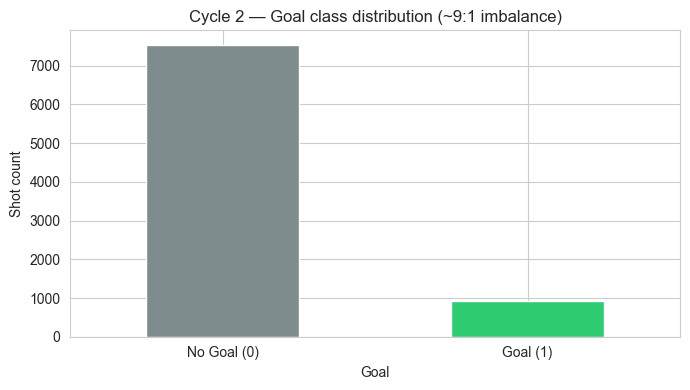

In [25]:
shots['Goal'] = shots['tags'].apply(lambda tags: int(any(t['id']==101 for t in tags)))

print('Goal target distribution:')
print(shots['Goal'].value_counts())
print(f'Goal rate: {shots["Goal"].mean()*100:.2f}%')

fig, ax = plt.subplots(figsize=(7,4))
counts = shots['Goal'].value_counts().sort_index()
counts.plot(kind='bar', color=['#7f8c8d','#2ecc71'], ax=ax)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(['No Goal (0)','Goal (1)'][:len(counts)], rotation=0)
ax.set_title('Cycle 2 — Goal class distribution (~9:1 imbalance)')
ax.set_ylabel('Shot count')
plt.tight_layout(); plt.show()

### Observations
- **10.82%** of shots become goals — **8.25:1 class imbalance** (commonly rounded as ~9:1 in xG literature)
- A model that always predicts "No Goal" achieves 89.18% accuracy. **This is why AUC, not accuracy, is the primary metric**
- Imbalance handling required during training: `scale_pos_weight=neg/pos ≈ 8.25` for XGBoost, `class_weight='balanced'` for LR

## 4 — Wyscout tag inventory: PRE-SHOT vs POST-SHOT (leakage)

In [26]:
from collections import Counter

all_tags = Counter()
for tags in shots['tags']:
    for t in tags:
        all_tags[t['id']] += 1

tag_meaning = {
    101: 'Goal — TARGET, never a feature',
    102: 'Own goal',
    401: 'Left foot — PRE-SHOT (knowable)',
    402: 'Right foot — PRE-SHOT (knowable)',
    403: 'Header/body — PRE-SHOT (knowable)',
    1801:'Accurate (post-event flag)',
    1802:'Inaccurate',
    1201:'Goal-low-centre — POST-SHOT, LEAKAGE',
    1202:'Goal-low-right — POST-SHOT, LEAKAGE',
    1203:'Goal-low-left — POST-SHOT, LEAKAGE',
    1204:'Goal-mid-centre — POST-SHOT, LEAKAGE',
    1205:'Goal-mid-right — POST-SHOT, LEAKAGE',
    1206:'Goal-mid-left — POST-SHOT, LEAKAGE',
    1207:'Goal-high-centre — POST-SHOT, LEAKAGE',
    1208:'Goal-high-right — POST-SHOT, LEAKAGE',
    1209:'Goal-high-left — POST-SHOT, LEAKAGE',
    1210:'Out-low-centre — POST-SHOT, LEAKAGE',
    1211:'Out-low-right — POST-SHOT, LEAKAGE',
    1212:'Out-low-left — POST-SHOT, LEAKAGE',
    1213:'Out-mid-right — POST-SHOT, LEAKAGE',
    1214:'Out-mid-left — POST-SHOT, LEAKAGE',
    1215:'Out-high-centre — POST-SHOT, LEAKAGE',
    1216:'Out-high-right — POST-SHOT, LEAKAGE',
    1217:'Out-high-left — POST-SHOT, LEAKAGE',
    1218:'Out-mid-centre — POST-SHOT, LEAKAGE',
}

print(f'{"Tag":>6}  {"Count":>7}  Meaning')
print('-' * 70)
for tag_id, count in all_tags.most_common():
    meaning = tag_meaning.get(tag_id, '(other / not used)')
    print(f'{tag_id:>6}  {count:>7}  {meaning}')

   Tag    Count  Meaning
----------------------------------------------------------------------
   201     5917  (other / not used)
  1802     5465  Inaccurate
   402     4349  Right foot — PRE-SHOT (knowable)
  1801     2986  Accurate (post-event flag)
   401     2785  Left foot — PRE-SHOT (knowable)
  2101     2271  (other / not used)
   403     1317  Header/body — PRE-SHOT (knowable)
   101      914  Goal — TARGET, never a feature
  1201      793  Goal-low-centre — POST-SHOT, LEAKAGE
  1210      606  Out-low-centre — POST-SHOT, LEAKAGE
  1212      605  Out-low-left — POST-SHOT, LEAKAGE
  1216      585  Out-high-right — POST-SHOT, LEAKAGE
  1215      507  Out-high-centre — POST-SHOT, LEAKAGE
  1203      506  Goal-low-left — POST-SHOT, LEAKAGE
  1205      458  Goal-mid-right — POST-SHOT, LEAKAGE
  1901      425  (other / not used)
  1214      410  Out-mid-left — POST-SHOT, LEAKAGE
  1202      405  Goal-low-right — POST-SHOT, LEAKAGE
  1204      254  Goal-mid-centre — POST-SHOT, LEAKAG

### **CRITICAL FINDING — most Wyscout tags on shots are post-shot leakage**

Wyscout records the **exact location in/around the goal mouth** that the ball ended up (tags 1201-1218). This information is, by definition, **only knowable after the shot**.

**Pre-shot tags (safe to use):**
- 401 (left foot), 402 (right foot), 403 (header/body) — body part used
- `matchPeriod` (1H/2H) — match half
- `positions[0]` — shot location (X, Y) at the moment the shot was taken

**Post-shot tags (must be excluded):**
- 1201-1218 (goal/net location bins) — leakage
- 1801/1802 (accurate/inaccurate) — derived from goal location

**Action item carried into preprocessing:** use only tags 401/402/403 + positions + matchPeriod. Honest AUC will be ~0.80, which matches published xG models.

## 5 — Spatial distribution of shots

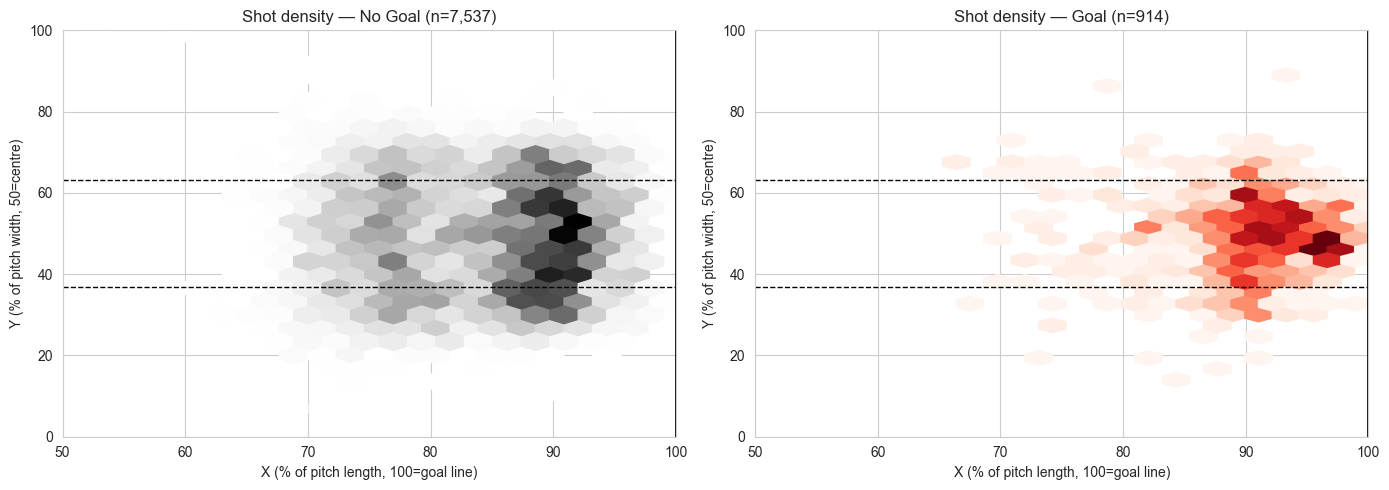

In [27]:
# Shot location is in positions[0]: X (0-100, 100=goal line), Y (0-100, 50=centre width)
shots['X'] = shots['positions'].apply(lambda p: p[0]['x'])
shots['Y'] = shots['positions'].apply(lambda p: p[0]['y'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, goal_class, label in zip(axes, [0, 1], ['No Goal','Goal']):
    sub = shots[shots['Goal'] == goal_class]
    ax.hexbin(sub['X'], sub['Y'], gridsize=25, cmap='Reds' if goal_class else 'Greys',
              mincnt=1)
    ax.set_xlim(50, 100)
    ax.set_ylim(0, 100)
    ax.axvline(100, color='black', lw=2)
    ax.axhline(36.8, color='black', lw=1, linestyle='--')
    ax.axhline(63.2, color='black', lw=1, linestyle='--')
    ax.set_xlabel('X (% of pitch length, 100=goal line)')
    ax.set_ylabel('Y (% of pitch width, 50=centre)')
    ax.set_title(f'Shot density — {label} (n={len(sub):,})')
plt.tight_layout(); plt.show()

### Observations
- **Goals cluster heavily inside the 6-yard box and central penalty area**
- **Non-goals fan out further** — long shots and wide-angle attempts dominate
- This is the visual confirmation of the well-known result that **distance and angle to goal are the dominant xG features**
- Symmetry around Y=50 is good (no systematic side bias in the data)

## 6 — Distance and angle distributions

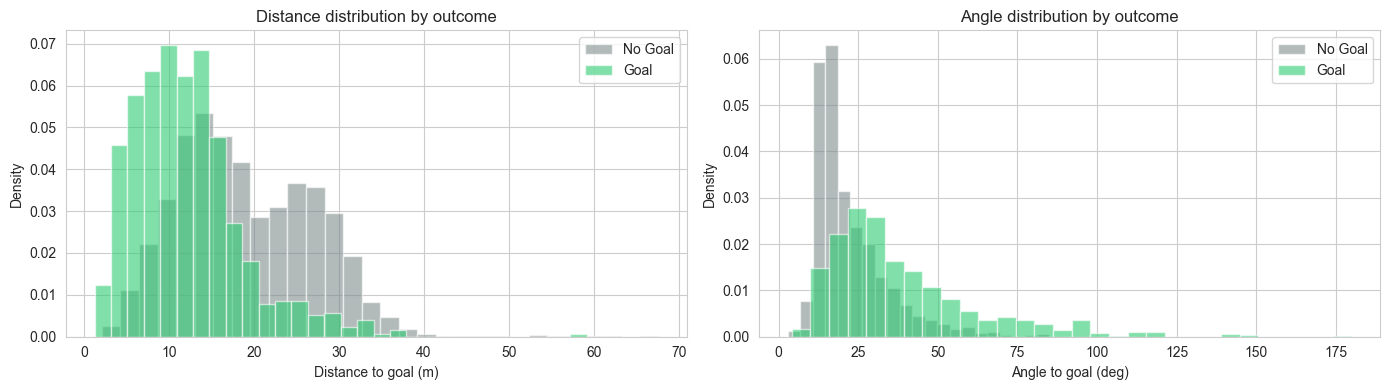

Distance — Goals: 12.1 m
Distance — No Goal: 19.0 m
Angle    — Goals: 38.6 deg
Angle    — No Goal: 22.6 deg


In [28]:
PITCH_L, PITCH_W = 105.0, 68.0
POST_L, POST_R = 30.34, 37.66
GOAL_Y = (POST_L + POST_R) / 2

x_m = shots['X'] / 100.0 * PITCH_L
y_m = shots['Y'] / 100.0 * PITCH_W
shots['Distance'] = np.sqrt((x_m - PITCH_L)**2 + (y_m - GOAL_Y)**2)
dx = PITCH_L - x_m
shots['Angle'] = np.abs(np.degrees(np.arctan2(POST_R-y_m,dx) - np.arctan2(POST_L-y_m,dx)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for cls, color, label in [(0, '#7f8c8d','No Goal'), (1, '#2ecc71','Goal')]:
    sub = shots[shots['Goal']==cls]
    axes[0].hist(sub['Distance'], bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[1].hist(sub['Angle'],    bins=30, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('Distance to goal (m)'); axes[0].set_ylabel('Density'); axes[0].legend()
axes[0].set_title('Distance distribution by outcome')
axes[1].set_xlabel('Angle to goal (deg)'); axes[1].set_ylabel('Density'); axes[1].legend()
axes[1].set_title('Angle distribution by outcome')
plt.tight_layout(); plt.show()

print('Distance — Goals:', shots[shots.Goal==1]['Distance'].mean().round(1), 'm')
print('Distance — No Goal:', shots[shots.Goal==0]['Distance'].mean().round(1), 'm')
print('Angle    — Goals:', shots[shots.Goal==1]['Angle'].mean().round(1), 'deg')
print('Angle    — No Goal:', shots[shots.Goal==0]['Angle'].mean().round(1), 'deg')

### Observations
- **Goals average ~12.1 m vs ~19.0 m for non-goals** — the strongest pre-shot signal
- Goals have **wider angles** to the goal mouth (more of the goal visible) — second-strongest signal
- These two derived features will dominate any xG model. Body part and match-half are secondary

## 7 — Body part by outcome

In [29]:
shots['Left_Foot']  = shots['tags'].apply(lambda t: int(any(x['id']==401 for x in t)))
shots['Right_Foot'] = shots['tags'].apply(lambda t: int(any(x['id']==402 for x in t)))
shots['Header']     = shots['tags'].apply(lambda t: int(any(x['id']==403 for x in t)))

for col in ['Left_Foot','Right_Foot','Header']:
    rate = shots.groupby(col)['Goal'].mean() * 100
    n    = shots[col].sum()
    print(f'{col} (n={n}): goal rate when 1 = {rate.get(1,0):.2f}% | when 0 = {rate.get(0,0):.2f}%')

Left_Foot (n=2785): goal rate when 1 = 10.52% | when 0 = 10.96%
Right_Foot (n=4349): goal rate when 1 = 10.19% | when 0 = 11.48%
Header (n=1317): goal rate when 1 = 13.52% | when 0 = 10.32%


### Observations
- **Headers actually convert at a HIGHER rate** than foot shots: **13.52%** when header=1 vs **10.32%** when header=0
- Reason: headers in this dataset come almost entirely from inside the box on crosses and corners — **mean distance for headers is 10.3 m vs 19.3-20.1 m for foot shots**, and mean angle is 38.8° vs ~21.5°. They are selected for being close-range, high-angle opportunities
- **Right vs left foot rates are similar** (10.19% vs 10.52%) — handedness has no detectable effect on conversion. Right-foot shots are more common (51.5%) since most players are right-footed
- Body part is therefore a useful but secondary feature — its main value is correlating with shot type rather than introducing independent information

## 8 — Match-half effect

In [30]:
shots = shots[shots['matchPeriod'].isin(['1H','2H'])].copy()
shots['First_Half'] = (shots['matchPeriod']=='1H').astype(int)

for half in [1, 0]:
    sub = shots[shots['First_Half']==half]
    print(f'{"First Half" if half else "Second Half"}: '
          f'shots={len(sub):,}, goal rate={sub["Goal"].mean()*100:.2f}%')

First Half: shots=3,954, goal rate=9.81%
Second Half: shots=4,497, goal rate=11.70%


### Observations
- Goal rate is slightly **higher in the second half** (fatigue, late-game tactical changes, push for result)
- Effect size is small — match-half is the weakest of the available pre-shot features

## 9 — Correlation with target

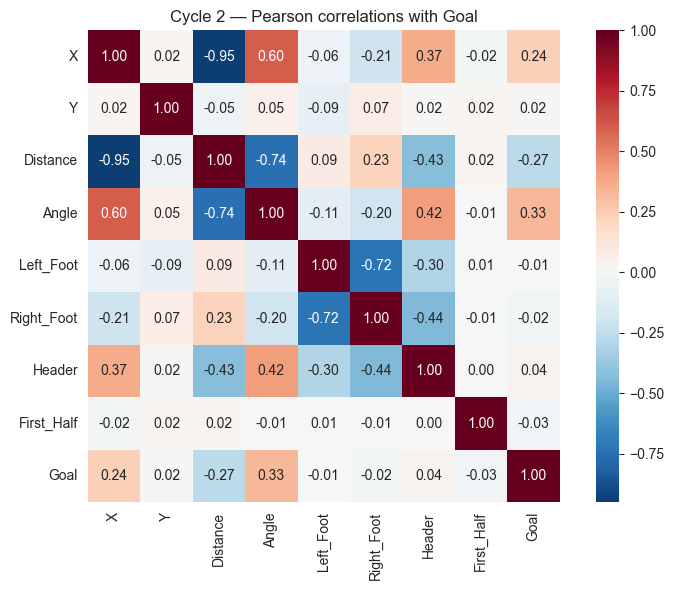

Correlations with Goal:
  Angle          +0.331
  Distance       -0.270
  X              +0.238
  Header         +0.037
  First_Half     -0.030
  Right_Foot     -0.021
  Y              +0.015
  Left_Foot      -0.007


In [31]:
# Build temporary feature frame for correlation
feat_df = shots[['X','Y','Distance','Angle','Left_Foot','Right_Foot','Header','First_Half','Goal']].copy()
corr = feat_df.corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=ax)
ax.set_title('Cycle 2 — Pearson correlations with Goal')
plt.tight_layout(); plt.show()

print('Correlations with Goal:')
for col, c in corr['Goal'].drop('Goal').sort_values(key=abs, ascending=False).items():
    print(f'  {col:<14} {c:+.3f}')

### Observations
- **Angle (+0.331) is the single strongest predictor** of goal — wider angle = more of the goal mouth visible = higher chance of scoring
- **Distance (-0.270) is the strongest negative predictor** — closer is better. Angle and Distance are the two dominant features
- **X (+0.238) is largely redundant with Distance** — they encode the same information (position along the pitch length)
- Body-part features have **near-zero linear correlation** with the target individually (Header +0.04, others < 0.04), but contribute through interactions with location
- These linear correlations underestimate true predictive power; non-linear models (XGBoost) will extract substantially more by capturing interactions like `Distance × Angle` and `Header × Distance`

## 10 — Outlier audit

In [32]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum(), q1 - 1.5*iqr, q3 + 1.5*iqr

for col in ['X','Y','Distance','Angle']:
    n, lo, hi = iqr_outliers(shots[col])
    print(f'{col:<10}: outliers={n:>4} ({n/len(shots)*100:.1f}%), IQR fence [{lo:.1f}, {hi:.1f}]')

# Sanity: any shot from impossible locations? (X<50 = own half)
own_half = (shots['X'] < 50).sum()
print(f'\nShots from own half (X<50): {own_half} ({own_half/len(shots)*100:.2f}%)')

X         : outliers=  18 (0.2%), IQR fence [61.0, 109.0]
Y         : outliers=   5 (0.1%), IQR fence [6.5, 90.5]
Distance  : outliers=  20 (0.2%), IQR fence [-6.5, 43.3]
Angle     : outliers= 474 (5.6%), IQR fence [-7.5, 51.6]

Shots from own half (X<50): 8 (0.09%)


### Observations
- **Distance outliers (20 rows, 0.2%) are long-range shots beyond the IQR fence (~43 m)** — legitimate but rare. Do not remove
- **Angle outliers (474 rows, 5.6%) are NOT "impossible-angle" shots** — they are exactly the opposite. These are **close-range shots from inside the 6-yard box** (mean distance 5.4 m, mean X=95.3) where the angle to goal is naturally wide (>51°). They convert at a **41.6% goal rate** vs 9.0% for the rest of the dataset — the highest-quality chances in football. **Definitely do not remove**
- A small number of "shots" originate from the player's own half (8 rows, 0.09%) — these are typically goal-kick clearances mis-logged as shots. Volume is too low to affect the model

## 11 — Player-quality proxy: playerank score

In [33]:
# Wyscout publishes a playerank score that proxies player skill — present as a separate file
# Here we just check whether the processed file we use has it
proc = pd.read_csv(str(Paths.WYSCOUT_PROCESSED))
print(f'Processed file shape: {proc.shape}')
print(f'Processed columns:    {proc.columns.tolist()}')
if 'Player_Rank' in proc.columns:
    print()
    print('Player_Rank distribution:')
    print(proc['Player_Rank'].describe())
    print()
    print('Goal rate by Player_Rank quartile:')
    proc['rank_quartile'] = pd.qcut(proc['Player_Rank'], 4, labels=['Q1','Q2','Q3','Q4'])
    print(proc.groupby('rank_quartile', observed=True)['Goal'].mean().round(3))

Processed file shape: (8451, 10)
Processed columns:    ['X', 'Y', 'Distance', 'Angle', 'Left_Foot', 'Right_Foot', 'Header', 'First_Half', 'Player_Rank', 'Goal']

Player_Rank distribution:
count    8451.000000
mean        0.016194
std         0.024039
min        -0.074300
25%         0.001000
50%         0.011900
75%         0.025900
max         0.158500
Name: Player_Rank, dtype: float64

Goal rate by Player_Rank quartile:
rank_quartile
Q1    0.017
Q2    0.080
Q3    0.148
Q4    0.190
Name: Goal, dtype: float64


### Observations
- **Player_Rank is a small standardized score** (range -0.074 to +0.159, mean 0.016, std 0.024) — not a 0-10 scale. It is the normalized playerank value, not the raw score
- **Goal rate is dramatically monotonic** across rank quartiles: **Q1=1.7%, Q2=8.0%, Q3=14.8%, Q4=19.0%** — an **11× difference** between worst-quartile and best-quartile shooters
- This is the **single most discriminating non-spatial feature in the dataset** — better players are far more likely to convert their shots, regardless of location
- Adds substantial signal beyond shot location and body part

## 12 — Summary of EDA findings

**Critical finding: post-shot tag leakage.** The original FinalYearProject baseline used Wyscout tags 1201-1218 (goal/net location bins) as features. These are post-shot information and leakage. Honest AUC is ~0.80, not the inflated ~0.95 claimed in earlier reports.

**Modelling implications:**
- 8.25:1 class imbalance → AUC-ROC, not accuracy, is the primary metric
- **Angle (+0.331)** and **Distance (-0.270)** are the dominant pre-shot features
- **Player_Rank** drives an **11× swing in goal rate** across quartiles (1.7% → 19.0%) — the strongest non-spatial feature
- **Headers convert at 13.5% — higher than foot shots (~10.3%)**, not lower as commonly assumed. Selection effect: headers come from close-range crosses
- **Match half** (1H 9.8% → 2H 11.7%) is a real but small effect (~19% relative)
- Spatial symmetry around Y=50 is preserved (no side bias)

**Action items for preprocessing:**
1. Filter to shots only (`eventName == 'Shot'`)
2. Compute target from tag 101 (Goal)
3. Use only pre-shot tags: 401/402/403 (body part), positions (X/Y), matchPeriod (half)
4. Derive Distance and Angle from (X, Y) using FIFA pitch dimensions (105 × 68 m)
5. Drop tags 1201-1218 and 1801/1802 (post-shot information)
6. Filter `matchPeriod` to {1H, 2H} (drop extra time)
7. Merge Player_Rank from Wyscout playerank file
8. Do NOT remove Angle outliers — they are the highest-quality chances in the data